### IMPORT LIBRARY 


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Library berhasil di-import.")

Library berhasil di-import.


### LOAD DATASET

membuat pipeline voting ensemble dari hasil prediksi tiga model, lalu mengevaluasi performanya terhadap label asli dari data test.

In [ ]:
BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DF_TEST_PATH = PROCESSED_DIR / "df_test_lengkap.csv"
TEST_PREDICTIONS_PATH = PROCESSED_DIR / "test_predictions.csv"

print("Setup path berhasil.")
print("BASE_DIR              :", BASE_DIR)
print("PROCESSED_DIR         :", PROCESSED_DIR)
print("OUTPUTS_DIR           :", OUTPUTS_DIR)
print("DF_TEST_PATH          :", DF_TEST_PATH)
print("TEST_PREDICTIONS_PATH :", TEST_PREDICTIONS_PATH)

Setup path berhasil.
BASE_DIR              : E:\project-kda-kelompok3
PROCESSED_DIR         : E:\project-kda-kelompok3\data\processed
OUTPUTS_DIR           : E:\project-kda-kelompok3\outputs
DF_TEST_PATH          : E:\project-kda-kelompok3\data\processed\df_test_lengkap.csv
TEST_PREDICTIONS_PATH : E:\project-kda-kelompok3\data\processed\test_predictions.csv


In [ ]:
if DF_TEST_PATH.exists():
    print("df_test_lengkap.csv ditemukan.")
else:
    print("df_test_lengkap.csv tidak ditemukan:", DF_TEST_PATH)

if TEST_PREDICTIONS_PATH.exists():
    print("test_predictions.csv ditemukan.")
else:
    print("test_predictions.csv tidak ditemukan:", TEST_PREDICTIONS_PATH)

df_test_lengkap.csv ditemukan.
test_predictions.csv ditemukan.


In [ ]:
df_test = pd.read_csv(DF_TEST_PATH)
test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)

print("Dataset berhasil dimuat.")

print("\nShape df_test_lengkap:")
print(df_test.shape)

print("\nShape test_predictions:")
print(test_predictions.shape)

Dataset berhasil dimuat.

Shape df_test_lengkap:
(4999, 14)

Shape test_predictions:
(4999, 17)


In [ ]:
print("Preview df_test_lengkap:")
display(df_test.head())

print("\nPreview test_predictions:")
display(test_predictions.head())

Preview df_test_lengkap:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2



Preview test_predictions:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,Normal,Normal,Normal
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,Attack,Attack,Attack
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,Attack,Attack,Attack
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,Fault,Fault,Fault
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,Fault,Fault,Fault


In [ ]:
print("Kolom df_test_lengkap:")
print(df_test.columns.tolist())

print("\nKolom test_predictions:")
print(test_predictions.columns.tolist())

Kolom df_test_lengkap:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label']

Kolom test_predictions:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label', 'DT_prediction', 'RF_prediction', 'LR_prediction']


In [ ]:
target_column = "label"

prediction_columns = [
    "DT_prediction",
    "RF_prediction",
    "LR_prediction"
]

required_columns = [target_column] + prediction_columns

missing_columns = [
    col for col in required_columns
    if col not in test_predictions.columns
]

if len(missing_columns) == 0:
    print("Semua kolom yang dibutuhkan tersedia.")
else:
    print("Ada kolom yang belum tersedia:")
    print(missing_columns)

Semua kolom yang dibutuhkan tersedia.


## TRANSFORMATION FOR PREDICTION TEST 

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display

BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

TEST_PREDICTIONS_PATH = PROCESSED_DIR / "test_predictions.csv"
TEST_PREDICTIONS_NUMERIC_PATH = PROCESSED_DIR / "test_predictions_numeric.csv"

test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)

print("File test_predictions.csv berhasil dimuat.")
print("Path:", TEST_PREDICTIONS_PATH)
print("Shape:", test_predictions.shape)

display(test_predictions.head())

File test_predictions.csv berhasil dimuat.
Path: E:\project-kda-kelompok3\data\processed\test_predictions.csv
Shape: (4999, 17)


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,Normal,Normal,Normal
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,Attack,Attack,Attack
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,Attack,Attack,Attack
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,Fault,Fault,Fault
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,Fault,Fault,Fault


In [ ]:
label_mapping = {
    "Normal": 0,
    "Attack": 1,
    "Fault": 2,
    "normal": 0,
    "attack": 1,
    "fault": 2
}

prediction_columns = [
    "DT_prediction",
    "RF_prediction",
    "LR_prediction"
]

test_predictions_numeric = test_predictions.copy()

for col in prediction_columns:
    test_predictions_numeric[col] = test_predictions_numeric[col].map(label_mapping)

print("Kolom prediction berhasil diubah dari teks menjadi angka.")

display(
    test_predictions_numeric[
        [
            "label",
            "DT_prediction",
            "RF_prediction",
            "LR_prediction"
        ]
    ].head(10)
)

Kolom prediction berhasil diubah dari teks menjadi angka.


,label,DT_prediction,RF_prediction,LR_prediction
0,0,0,0,0
1,1,1,1,1
2,1,1,1,1
3,2,2,2,2
4,2,2,2,2
5,2,2,2,2
6,0,0,0,0
7,0,0,0,0
8,2,0,0,2
9,0,0,0,0


In [ ]:
valid_labels = [0, 1, 2]

print("Tipe data kolom label dan prediction:")
print(test_predictions_numeric[["label"] + prediction_columns].dtypes)

print("\nNilai unik setelah transformasi:")

for col in ["label"] + prediction_columns:
    unique_values = sorted(test_predictions_numeric[col].dropna().unique())
    print(f"{col}: {unique_values}")

    invalid_values = [
        value for value in unique_values
        if value not in valid_labels
    ]

    if len(invalid_values) == 0:
        print(f"{col} valid.")
    else:
        print(f"{col} memiliki nilai tidak valid:", invalid_values)

print("\nMissing value setelah transformasi:")
print(test_predictions_numeric[prediction_columns].isnull().sum())

Tipe data kolom label dan prediction:
label            int64
DT_prediction    int64
RF_prediction    int64
LR_prediction    int64
dtype: object

Nilai unik setelah transformasi:
label: [np.int64(0), np.int64(1), np.int64(2)]
label valid.
DT_prediction: [np.int64(0), np.int64(1), np.int64(2)]
DT_prediction valid.
RF_prediction: [np.int64(0), np.int64(1), np.int64(2)]
RF_prediction valid.
LR_prediction: [np.int64(0), np.int64(1), np.int64(2)]
LR_prediction valid.

Missing value setelah transformasi:
DT_prediction    0
RF_prediction    0
LR_prediction    0
dtype: int64


In [ ]:
for col in prediction_columns:
    test_predictions_numeric[col] = test_predictions_numeric[col].astype(int)

test_predictions_numeric["label"] = test_predictions_numeric["label"].astype(int)

print("Kolom label dan prediction berhasil dipastikan bertipe integer.")

print(test_predictions_numeric[["label"] + prediction_columns].dtypes)

Kolom label dan prediction berhasil dipastikan bertipe integer.
label            int64
DT_prediction    int64
RF_prediction    int64
LR_prediction    int64
dtype: object


In [ ]:
test_predictions_numeric.to_csv(
    TEST_PREDICTIONS_NUMERIC_PATH,
    index=False
)

print("CSV hasil transformasi berhasil disimpan ke:")
print(TEST_PREDICTIONS_NUMERIC_PATH)

CSV hasil transformasi berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\test_predictions_numeric.csv


In [ ]:
saved_numeric_predictions = pd.read_csv(TEST_PREDICTIONS_NUMERIC_PATH)

print("Preview test_predictions_numeric.csv:")
display(saved_numeric_predictions.head(10))

print("\nShape:", saved_numeric_predictions.shape)

print("\nTipe data:")
print(saved_numeric_predictions[["label"] + prediction_columns].dtypes)

Preview test_predictions_numeric.csv:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,2,2,2
5,2024-01-02 15:56:00,SGD-0011,230.0803,7.6149,1499.1946,50.0596,29.530,26.12,1.26,73.60,0,1,0,2,2,2,2
6,2024-01-01 07:36:00,SGD-0010,220.7088,6.0614,984.6023,49.8844,27.411,14.65,0.50,95.79,0,1,0,0,0,0,0
7,2024-01-01 14:35:50,SGD-0013,218.1892,3.6406,549.3208,49.9491,34.491,8.93,0.57,87.63,0,1,0,0,0,0,0
8,2024-01-02 17:38:25,SGD-0037,212.9653,7.4998,1523.7886,49.9371,39.060,20.68,0.82,93.34,1,1,0,2,0,0,2
9,2024-01-01 10:22:55,SGD-0015,220.6344,2.4547,538.0052,50.0001,28.863,27.91,0.10,92.92,0,1,0,0,0,0,0



Shape: (4999, 17)

Tipe data:
label            int64
DT_prediction    int64
RF_prediction    int64
LR_prediction    int64
dtype: object


### MAJORITY VOTING

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_PREDICTIONS_NUMERIC_PATH = PROCESSED_DIR / "test_predictions_numeric.csv"

prediction_data = pd.read_csv(TEST_PREDICTIONS_NUMERIC_PATH)

print("Dataset test_predictions_numeric.csv berhasil dimuat.")
print("Path:", TEST_PREDICTIONS_NUMERIC_PATH)
print("Shape:", prediction_data.shape)

display(prediction_data.head(10))

Dataset test_predictions_numeric.csv berhasil dimuat.
Path: E:\project-kda-kelompok3\data\processed\test_predictions_numeric.csv
Shape: (4999, 17)


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,2,2,2
5,2024-01-02 15:56:00,SGD-0011,230.0803,7.6149,1499.1946,50.0596,29.530,26.12,1.26,73.60,0,1,0,2,2,2,2
6,2024-01-01 07:36:00,SGD-0010,220.7088,6.0614,984.6023,49.8844,27.411,14.65,0.50,95.79,0,1,0,0,0,0,0
7,2024-01-01 14:35:50,SGD-0013,218.1892,3.6406,549.3208,49.9491,34.491,8.93,0.57,87.63,0,1,0,0,0,0,0
8,2024-01-02 17:38:25,SGD-0037,212.9653,7.4998,1523.7886,49.9371,39.060,20.68,0.82,93.34,1,1,0,2,0,0,2
9,2024-01-01 10:22:55,SGD-0015,220.6344,2.4547,538.0052,50.0001,28.863,27.91,0.10,92.92,0,1,0,0,0,0,0


In [ ]:
target_column = "label"

prediction_columns = [
    "DT_prediction",
    "RF_prediction",
    "LR_prediction"
]

required_columns = [target_column] + prediction_columns

missing_columns = [
    col for col in required_columns
    if col not in prediction_data.columns
]

if len(missing_columns) == 0:
    print("Semua kolom yang dibutuhkan tersedia.")
else:
    print("Ada kolom yang belum tersedia:")
    print(missing_columns)

print("\nTipe data:")
print(prediction_data[required_columns].dtypes)

print("\nNilai unik:")
for col in required_columns:
    print(col, ":", sorted(prediction_data[col].dropna().unique()))

Semua kolom yang dibutuhkan tersedia.

Tipe data:
label            int64
DT_prediction    int64
RF_prediction    int64
LR_prediction    int64
dtype: object

Nilai unik:
label : [np.int64(0), np.int64(1), np.int64(2)]
DT_prediction : [np.int64(0), np.int64(1), np.int64(2)]
RF_prediction : [np.int64(0), np.int64(1), np.int64(2)]
LR_prediction : [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
voting_data = prediction_data.copy()

def majority_vote(row):
    votes = [
        row["DT_prediction"],
        row["RF_prediction"],
        row["LR_prediction"]
    ]

    return pd.Series(votes).mode()[0]


voting_data["ensemble_prediction"] = voting_data.apply(
    majority_vote,
    axis=1
).astype(int)

print("Manual hard voting berhasil dilakukan.")

display(
    voting_data[
        [
            "label",
            "DT_prediction",
            "RF_prediction",
            "LR_prediction",
            "ensemble_prediction"
        ]
    ].head(10)
)

Manual hard voting berhasil dilakukan.


,label,DT_prediction,RF_prediction,LR_prediction,ensemble_prediction
0,0,0,0,0,0
1,1,1,1,1,1
2,1,1,1,1,1
3,2,2,2,2,2
4,2,2,2,2,2
5,2,2,2,2,2
6,0,0,0,0,0
7,0,0,0,0,0
8,2,0,0,2,0
9,0,0,0,0,0


In [ ]:
ENSEMBLE_RESULT_PATH = PROCESSED_DIR / "test_predictions_with_ensemble.csv"

voting_data.to_csv(
    ENSEMBLE_RESULT_PATH,
    index=False
)

print("Hasil ensemble berhasil disimpan ke:")
print(ENSEMBLE_RESULT_PATH)

print("\nPreview hasil ensemble:")
display(voting_data.head(10))

Hasil ensemble berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\test_predictions_with_ensemble.csv

Preview hasil ensemble:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction,ensemble_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,2,2,2,2
5,2024-01-02 15:56:00,SGD-0011,230.0803,7.6149,1499.1946,50.0596,29.530,26.12,1.26,73.60,0,1,0,2,2,2,2,2
6,2024-01-01 07:36:00,SGD-0010,220.7088,6.0614,984.6023,49.8844,27.411,14.65,0.50,95.79,0,1,0,0,0,0,0,0
7,2024-01-01 14:35:50,SGD-0013,218.1892,3.6406,549.3208,49.9491,34.491,8.93,0.57,87.63,0,1,0,0,0,0,0,0
8,2024-01-02 17:38:25,SGD-0037,212.9653,7.4998,1523.7886,49.9371,39.060,20.68,0.82,93.34,1,1,0,2,0,0,2,0
9,2024-01-01 10:22:55,SGD-0015,220.6344,2.4547,538.0052,50.0001,28.863,27.91,0.10,92.92,0,1,0,0,0,0,0,0


### SLICING THE DATA FOR DASHBOARD

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display

BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

ENSEMBLE_FULL_PATH = PROCESSED_DIR / "test_predictions_with_ensemble.csv"

FRIEND_OUTPUT_PATH = PROCESSED_DIR / "ensemble_result_for_friend.csv"

ensemble_full = pd.read_csv(ENSEMBLE_FULL_PATH)

print("File hasil ensemble berhasil dimuat.")
print("Path:", ENSEMBLE_FULL_PATH)
print("Shape:", ensemble_full.shape)

display(ensemble_full.head())

File hasil ensemble berhasil dimuat.
Path: E:\project-kda-kelompok3\data\processed\test_predictions_with_ensemble.csv
Shape: (4999, 18)


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction,ensemble_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,2,2,2,2


In [ ]:
friend_result = ensemble_full[
    [
        "timestamp",
        "device_id",
        "voltage",
        "latency",
        "label",
        "ensemble_prediction"
    ]
].copy()

# Rename kolom agar sesuai permintaan teman
friend_result = friend_result.rename(columns={
    "label": "status",
    "ensemble_prediction": "ensemble_pred"
})

print("Dataset ringkas untuk teman berhasil dibuat.")
print("Shape:", friend_result.shape)

display(friend_result.head(10))

Dataset ringkas untuk teman berhasil dibuat.
Shape: (4999, 6)


,timestamp,device_id,voltage,latency,status,ensemble_pred
0,2024-01-01 03:21:30,SGD-0029,218.2535,18.09,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,326.27,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,72.13,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,19.69,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,26.36,2,2
5,2024-01-02 15:56:00,SGD-0011,230.0803,26.12,2,2
6,2024-01-01 07:36:00,SGD-0010,220.7088,14.65,0,0
7,2024-01-01 14:35:50,SGD-0013,218.1892,8.93,0,0
8,2024-01-02 17:38:25,SGD-0037,212.9653,20.68,2,0
9,2024-01-01 10:22:55,SGD-0015,220.6344,27.91,0,0


In [ ]:
friend_result.to_csv(
    FRIEND_OUTPUT_PATH,
    index=False
)

print("CSV untuk teman berhasil disimpan ke:")
print(FRIEND_OUTPUT_PATH)

CSV untuk teman berhasil disimpan ke:
E:\project-kda-kelompok3\data\processed\ensemble_result_for_friend.csv


### PERFORMANCE METRICS RESULTS

In [ ]:

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Library berhasil di-import.")

Library berhasil di-import.


In [ ]:
BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DF_TEST_PATH = PROCESSED_DIR / "df_test_lengkap.csv"
WITH_ENSEMBLE_PATH = PROCESSED_DIR / "test_predictions_with_ensemble.csv"

print("Setup path berhasil.")
print("DF_TEST_PATH       :", DF_TEST_PATH)
print("WITH_ENSEMBLE_PATH :", WITH_ENSEMBLE_PATH)
print("OUTPUTS_DIR        :", OUTPUTS_DIR)

Setup path berhasil.
DF_TEST_PATH       : E:\project-kda-kelompok3\data\processed\df_test_lengkap.csv
WITH_ENSEMBLE_PATH : E:\project-kda-kelompok3\data\processed\test_predictions_with_ensemble.csv
OUTPUTS_DIR        : E:\project-kda-kelompok3\outputs


In [ ]:
df_test = pd.read_csv(DF_TEST_PATH)
with_ensemble = pd.read_csv(WITH_ENSEMBLE_PATH)

print("Dataset berhasil dimuat.")

print("\nShape df_test_lengkap:")
print(df_test.shape)

print("\nShape test_predictions_with_ensemble:")
print(with_ensemble.shape)

print("\nPreview df_test_lengkap:")
display(df_test.head())

print("\nPreview test_predictions_with_ensemble:")
display(with_ensemble.head())

Dataset berhasil dimuat.

Shape df_test_lengkap:
(4999, 14)

Shape test_predictions_with_ensemble:
(4999, 18)

Preview df_test_lengkap:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2



Preview test_predictions_with_ensemble:


,timestamp,device_id,voltage,current,power,frequency,temperature,latency,packet_loss,throughput,duplicate_packet,checksum_valid,authentication_fail,label,DT_prediction,RF_prediction,LR_prediction,ensemble_prediction
0,2024-01-01 03:21:30,SGD-0029,218.2535,4.3345,894.0249,49.8090,24.763,18.09,0.17,85.21,1,1,0,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,215.4426,6.9997,550.9740,49.9042,41.928,326.27,20.18,4.11,15,0,2,1,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,397.8761,2.9637,1096.7969,48.5056,68.808,72.13,9.62,30.33,0,0,1,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,200.1861,6.8417,624.8786,49.6281,47.873,19.69,1.19,92.78,0,1,0,2,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,230.0223,4.3586,1436.7103,50.0940,68.850,26.36,6.98,84.36,3,1,1,2,2,2,2,2


In [ ]:
print("Kolom df_test_lengkap:")
print(df_test.columns.tolist())

print("\nKolom test_predictions_with_ensemble:")
print(with_ensemble.columns.tolist())

Kolom df_test_lengkap:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label']

Kolom test_predictions_with_ensemble:
['timestamp', 'device_id', 'voltage', 'current', 'power', 'frequency', 'temperature', 'latency', 'packet_loss', 'throughput', 'duplicate_packet', 'checksum_valid', 'authentication_fail', 'label', 'DT_prediction', 'RF_prediction', 'LR_prediction', 'ensemble_prediction']


In [ ]:
target_column = "label"

prediction_columns = [
    "DT_prediction",
    "RF_prediction",
    "LR_prediction",
    "ensemble_prediction"
]

required_df_test_columns = [
    "timestamp",
    "device_id",
    target_column
]

required_prediction_columns = [
    "timestamp",
    "device_id"
] + prediction_columns

missing_df_test_columns = [
    col for col in required_df_test_columns
    if col not in df_test.columns
]

missing_prediction_columns = [
    col for col in required_prediction_columns
    if col not in with_ensemble.columns
]

if len(missing_df_test_columns) == 0:
    print("Kolom penting pada df_test_lengkap tersedia.")
else:
    print("Kolom yang hilang pada df_test_lengkap:")
    print(missing_df_test_columns)

if len(missing_prediction_columns) == 0:
    print("Kolom penting pada test_predictions_with_ensemble tersedia.")
else:
    print("Kolom yang hilang pada test_predictions_with_ensemble:")
    print(missing_prediction_columns)

Kolom penting pada df_test_lengkap tersedia.
Kolom penting pada test_predictions_with_ensemble tersedia.


In [ ]:
if len(df_test) == len(with_ensemble):
    print("Jumlah baris kedua dataset sama.")
    print("Jumlah baris:", len(df_test))
else:
    print("Jumlah baris kedua dataset berbeda.")
    print("df_test_lengkap              :", len(df_test))
    print("test_predictions_with_ensemble:", len(with_ensemble))

# Cek apakah timestamp dan device_id sama urutannya
same_timestamp = (df_test["timestamp"].values == with_ensemble["timestamp"].values).all()
same_device_id = (df_test["device_id"].values == with_ensemble["device_id"].values).all()

print("\nValidasi urutan data:")
print("Timestamp sama urutan:", same_timestamp)
print("Device ID sama urutan:", same_device_id)

if same_timestamp and same_device_id:
    print("Urutan data valid. Label asli bisa dibandingkan langsung dengan prediksi.")
else:
    print("Urutan data tidak sama. Perlu merge berdasarkan key sebelum evaluasi.")

Jumlah baris kedua dataset sama.
Jumlah baris: 4999

Validasi urutan data:
Timestamp sama urutan: True
Device ID sama urutan: True
Urutan data valid. Label asli bisa dibandingkan langsung dengan prediksi.


In [ ]:
evaluation_data = with_ensemble.copy()

evaluation_data["actual_label"] = df_test[target_column].values

print("Data evaluasi berhasil dibuat.")
print("Shape evaluation_data:", evaluation_data.shape)

display(
    evaluation_data[
        [
            "timestamp",
            "device_id",
            "actual_label",
            "DT_prediction",
            "RF_prediction",
            "LR_prediction",
            "ensemble_prediction"
        ]
    ].head(10)
)

Data evaluasi berhasil dibuat.
Shape evaluation_data: (4999, 19)


,timestamp,device_id,actual_label,DT_prediction,RF_prediction,LR_prediction,ensemble_prediction
0,2024-01-01 03:21:30,SGD-0029,0,0,0,0,0
1,2024-01-02 04:28:45,SGD-0042,1,1,1,1,1
2,2024-01-01 20:26:10,SGD-0036,1,1,1,1,1
3,2024-01-02 09:54:50,SGD-0014,2,2,2,2,2
4,2024-01-02 13:12:40,SGD-0030,2,2,2,2,2
5,2024-01-02 15:56:00,SGD-0011,2,2,2,2,2
6,2024-01-01 07:36:00,SGD-0010,0,0,0,0,0
7,2024-01-01 14:35:50,SGD-0013,0,0,0,0,0
8,2024-01-02 17:38:25,SGD-0037,2,0,0,2,0
9,2024-01-01 10:22:55,SGD-0015,0,0,0,0,0


In [ ]:
columns_to_convert = [
    "actual_label",
    "DT_prediction",
    "RF_prediction",
    "LR_prediction",
    "ensemble_prediction"
]

for col in columns_to_convert:
    evaluation_data[col] = evaluation_data[col].astype(int)

print("Label dan prediksi berhasil dipastikan bertipe integer.")

print("\nTipe data:")
print(evaluation_data[columns_to_convert].dtypes)

print("\nNilai unik:")
for col in columns_to_convert:
    print(col, ":", sorted(evaluation_data[col].unique()))

Label dan prediksi berhasil dipastikan bertipe integer.

Tipe data:
actual_label           int64
DT_prediction          int64
RF_prediction          int64
LR_prediction          int64
ensemble_prediction    int64
dtype: object

Nilai unik:
actual_label : [np.int64(0), np.int64(1), np.int64(2)]
DT_prediction : [np.int64(0), np.int64(1), np.int64(2)]
RF_prediction : [np.int64(0), np.int64(1), np.int64(2)]
LR_prediction : [np.int64(0), np.int64(1), np.int64(2)]
ensemble_prediction : [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
label_name_mapping = {
    0: "Normal",
    1: "Attack",
    2: "Fault"
}

print("Distribusi actual_label:")
print(
    evaluation_data["actual_label"]
    .value_counts()
    .sort_index()
    .rename(index=label_name_mapping)
)

for col in prediction_columns:
    print(f"\nDistribusi {col}:")
    print(
        evaluation_data[col]
        .value_counts()
        .sort_index()
        .rename(index=label_name_mapping)
    )

Distribusi actual_label:
actual_label
Normal    1602
Attack    2181
Fault     1216
Name: count, dtype: int64

Distribusi DT_prediction:
DT_prediction
Normal    1704
Attack    2149
Fault     1146
Name: count, dtype: int64

Distribusi RF_prediction:
RF_prediction
Normal    1685
Attack    2159
Fault     1155
Name: count, dtype: int64

Distribusi LR_prediction:
LR_prediction
Normal    1892
Attack    2130
Fault      977
Name: count, dtype: int64

Distribusi ensemble_prediction:
ensemble_prediction
Normal    1699
Attack    2151
Fault     1149
Name: count, dtype: int64


In [ ]:
y_true = evaluation_data["actual_label"]

model_prediction_map = {
    "Decision Tree": evaluation_data["DT_prediction"],
    "Random Forest": evaluation_data["RF_prediction"],
    "Logistic Regression": evaluation_data["LR_prediction"],
    "Manual Hard Voting Ensemble": evaluation_data["ensemble_prediction"]
}

evaluation_results = []

for model_name, y_pred in model_prediction_map.items():
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

evaluation_results_df = pd.DataFrame(evaluation_results)

print("Hasil evaluasi semua model:")
display(evaluation_results_df)

Hasil evaluasi semua model:


,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.955391,0.955761,0.955391,0.955061
1,Random Forest,0.961992,0.962275,0.961992,0.961774
2,Logistic Regression,0.904981,0.909626,0.904981,0.902893
3,Manual Hard Voting Ensemble,0.959192,0.959623,0.959192,0.958937


In [ ]:
## KHUSUS YANG ENSEMBLE SAJA
target_names = ["Normal", "Attack", "Fault"]

ensemble_report = classification_report(
    y_true,
    evaluation_data["ensemble_prediction"],
    labels=[0, 1, 2],
    target_names=target_names,
    zero_division=0
)

print("Classification Report - Manual Hard Voting Ensemble")
print("=" * 70)
print(ensemble_report)

Classification Report - Manual Hard Voting Ensemble
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97      1602
      Attack       0.97      0.96      0.97      2181
       Fault       0.96      0.90      0.93      1216

    accuracy                           0.96      4999
   macro avg       0.96      0.95      0.96      4999
weighted avg       0.96      0.96      0.96      4999



In [ ]:
ensemble_cm = confusion_matrix(
    y_true,
    evaluation_data["ensemble_prediction"],
    labels=[0, 1, 2]
)

ensemble_cm_df = pd.DataFrame(
    ensemble_cm,
    index=[f"Actual {name}" for name in target_names],
    columns=[f"Predicted {name}" for name in target_names]
)

print("Confusion Matrix Ensemble:")
display(ensemble_cm_df)

Confusion Matrix Ensemble:


,Predicted Normal,Predicted Attack,Predicted Fault
Actual Normal,1598,0,4
Actual Attack,39,2097,45
Actual Fault,62,54,1100


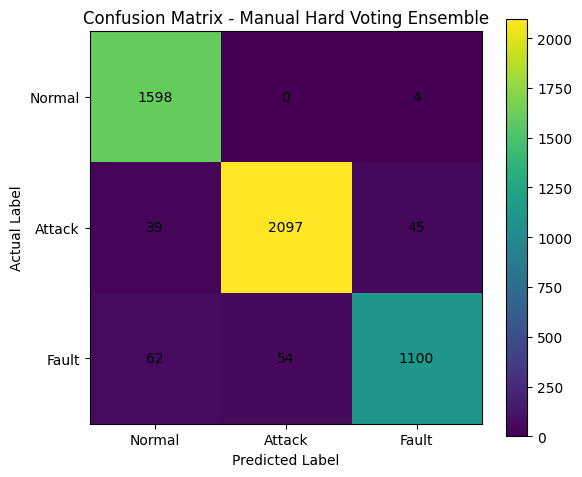

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(
    ensemble_cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix - Manual Hard Voting Ensemble")
plt.colorbar()

tick_marks = np.arange(len(target_names))

plt.xticks(
    tick_marks,
    target_names
)

plt.yticks(
    tick_marks,
    target_names
)

for i in range(ensemble_cm.shape[0]):
    for j in range(ensemble_cm.shape[1]):
        plt.text(
            j,
            i,
            ensemble_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

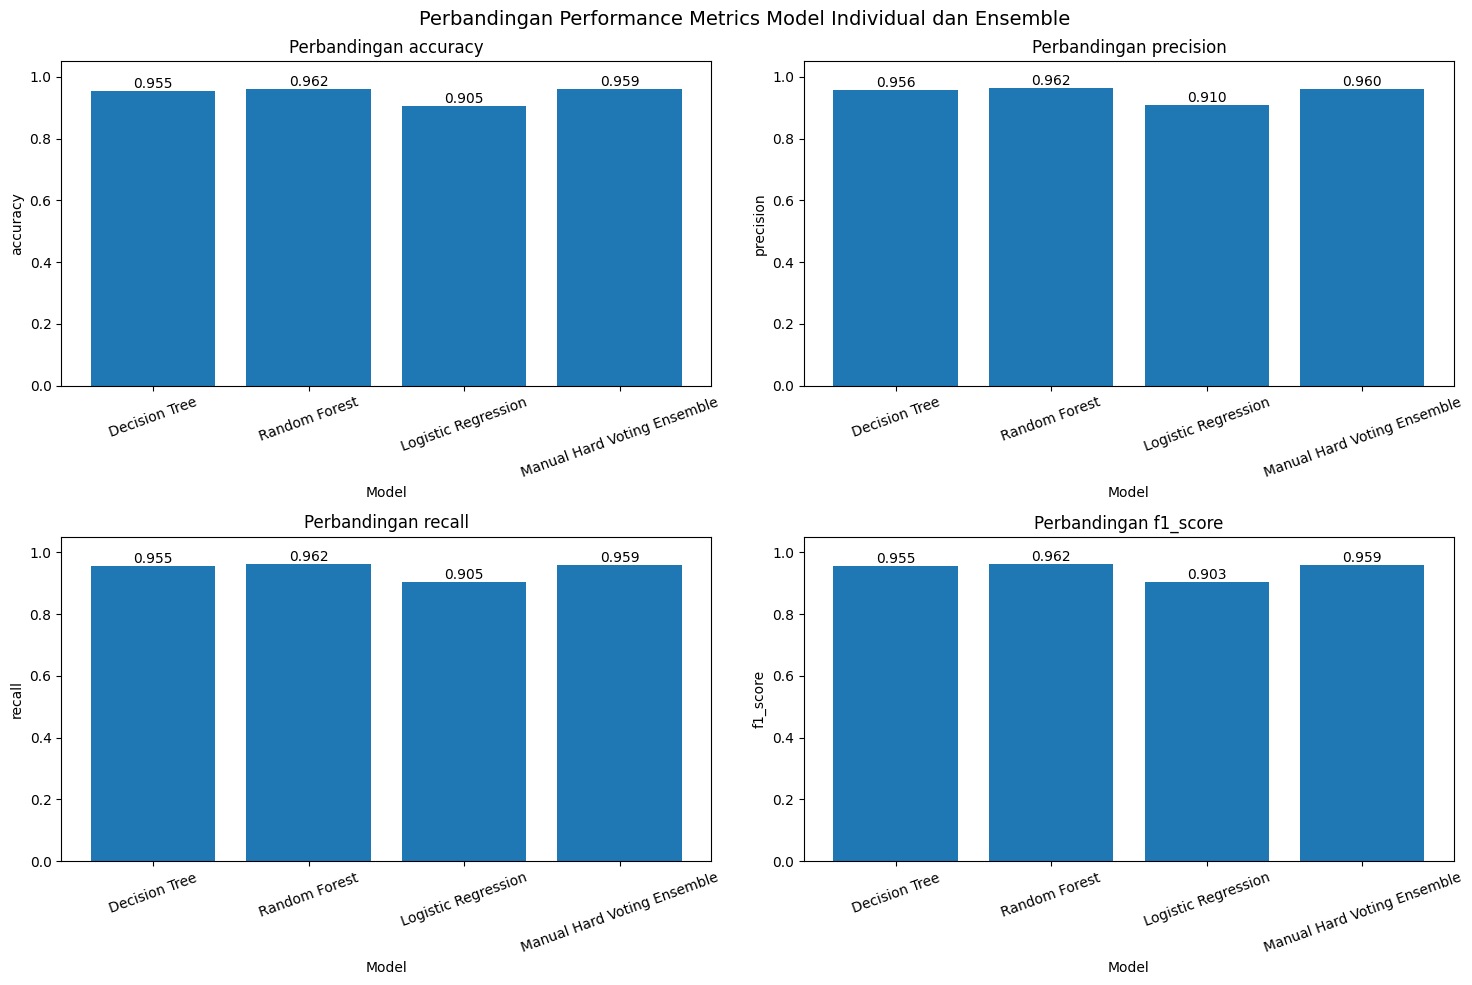

In [ ]:
metrics = ["accuracy", "precision", "recall", "f1_score"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].bar(
        evaluation_results_df["model"],
        evaluation_results_df[metric]
    )

    axes[i].set_title(f"Perbandingan {metric}")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].tick_params(axis="x", rotation=20)

    for index, value in enumerate(evaluation_results_df[metric]):
        axes[i].text(
            index,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )

plt.suptitle("Perbandingan Performance Metrics Model Individual dan Ensemble", fontsize=14)
plt.tight_layout()
plt.show()

### BEST MODEL 

In [ ]:


best_model = evaluation_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

print("Model terbaik berdasarkan F1-score:")
print("Model    :", best_model["model"])
print("Accuracy :", best_model["accuracy"])
print("Precision:", best_model["precision"])
print("Recall   :", best_model["recall"])
print("F1-score :", best_model["f1_score"])

Model terbaik berdasarkan F1-score:
Model    : Random Forest
Accuracy : 0.961992398479696
Precision: 0.9622746386265811
Recall   : 0.961992398479696
F1-score : 0.9617736276363237


In [ ]:
EVALUATION_RESULT_PATH = OUTPUTS_DIR / "performance_metrics_result.csv"
ENSEMBLE_REPORT_PATH = OUTPUTS_DIR / "ensemble_classification_report.txt"
ENSEMBLE_CM_PATH = OUTPUTS_DIR / "ensemble_confusion_matrix.csv"
EVALUATION_DATA_PATH = OUTPUTS_DIR / "evaluation_data_with_predictions.csv"

evaluation_results_df.to_csv(
    EVALUATION_RESULT_PATH,
    index=False
)

evaluation_data.to_csv(
    EVALUATION_DATA_PATH,
    index=False
)

ensemble_cm_df.to_csv(
    ENSEMBLE_CM_PATH,
    index=True
)

with open(ENSEMBLE_REPORT_PATH, "w") as file:
    file.write("MANUAL HARD VOTING ENSEMBLE CLASSIFICATION REPORT\n")
    file.write("=" * 70)
    file.write("\n\n")
    file.write(ensemble_report)

print("Hasil performance metrics disimpan ke:")
print(EVALUATION_RESULT_PATH)

print("\nData evaluasi lengkap disimpan ke:")
print(EVALUATION_DATA_PATH)

print("\nConfusion matrix disimpan ke:")
print(ENSEMBLE_CM_PATH)

print("\nClassification report disimpan ke:")
print(ENSEMBLE_REPORT_PATH)

Hasil performance metrics disimpan ke:
E:\project-kda-kelompok3\outputs\performance_metrics_result.csv

Data evaluasi lengkap disimpan ke:
E:\project-kda-kelompok3\outputs\evaluation_data_with_predictions.csv

Confusion matrix disimpan ke:
E:\project-kda-kelompok3\outputs\ensemble_confusion_matrix.csv

Classification report disimpan ke:
E:\project-kda-kelompok3\outputs\ensemble_classification_report.txt
